XGBoost = Extreme Gradient Boosting.
It is a supervised machine learning algorithm mainly used for classification and regressio
Binary classification: predict whether wildfire = 0 or wildfire = 1.
Trees are built one after another, with each new tree trying to improve the previous model.

In [11]:
import pandas as pd #data handling 
import numpy as np #numeric oprations

import matplotlib.pyplot as plt
import seaborn as sns

from xgboost import XGBClassifier #Machine learning model

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

from sklearn.model_selection import RandomizedSearchCV

import warnings
warnings.filterwarnings("ignore")

In [12]:
train = pd.read_csv(
    "../../data/processed/train.csv"
)

validation = pd.read_csv(
    "../../data/processed/validation.csv"
)

test = pd.read_csv(
    "../../data/processed/test.csv"
)


print(train.shape)
print(validation.shape)
print(test.shape)

(7319483, 21)
(1326842, 21)
(823955, 21)


In [13]:
print(train.columns.tolist())

['latitude', 'longitude', 'precipitation', 'relative_humidity_max', 'relative_humidity_min', 'specific_humidity', 'solar_radiation', 'temperature_min', 'temperature_max', 'wind_speed', 'burning_index', 'fuel_moisture_100hr', 'fuel_moisture_1000hr', 'energy_release_component', 'reference_evapotranspiration', 'potential_evapotranspiration', 'vapor_pressure_deficit', 'year', 'month', 'day_of_year', 'wildfire']


In [ ]:
#Remove target variable from features
X_train = train.drop(
    columns=["wildfire"]
) #remove target variable from  train dataset

y_train = train["wildfire"] #targert variable for train dataset


X_val = validation.drop(
    columns=["wildfire"]
)#remove target variable from  validation dataset

y_val = validation["wildfire"] #tragert variable for validation dataset


X_test = test.drop(
    columns=["wildfire"]
)##remove target variable from  test dataset

y_test = test["wildfire"] #target variable for test dataset

In [15]:
#confirm no target column in train and test and validation datasets
print(X_train.shape) 
print(X_val.shape)
print(X_test.shape)

(7319483, 20)
(1326842, 20)
(823955, 20)


In [16]:
print(
    X_train["year"].unique() #train dataset unique years
)


print(
    X_val["year"].unique() #validation dataset unique years
)


print(
    X_test["year"].unique()#test dataset unique years 2023 - 2025
)

[2018 2016 2014 2015 2017 2020 2019 2013]
[2022 2021]
[2023 2024 2025]


In [17]:
#wildfire imbalance exists

print("Training")
print(y_train.value_counts(normalize=True))


print("\nValidation")
print(y_val.value_counts(normalize=True))


print("\nTesting")
print(y_test.value_counts(normalize=True))

Training
wildfire
0    0.962509
1    0.037491
Name: proportion, dtype: float64

Validation
wildfire
0    0.918432
1    0.081568
Name: proportion, dtype: float64

Testing
wildfire
0    0.856315
1    0.143685
Name: proportion, dtype: float64


In [18]:
#Handle Class Imbalance for XGBoost
#For XGBoost we use: scale_pos_weight beacuse it is a binary classification problem. The scale_pos_weight parameter is used to control the balance of positive and negative weights, helping to address class imbalance in the dataset.
#Because wildfire is minority class.

In [20]:
negative = (y_train == 0).sum()

positive = (y_train == 1).sum()


scale_weight = negative / positive


scale_weight

np.float64(25.673139854380608)

In [ ]:
#Baseline XGBoost Model  Default model before tuning./before optimization.

xgb_baseline = XGBClassifier(

    random_state=42, #Makes results reproducible

    eval_metric="logloss", #Controls training evaluation.

    scale_pos_weight=scale_weight #Handles class imbalance.

)

In [22]:
#Train Model
xgb_baseline.fit(
    X_train,
    y_train
)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [61]:
#Validation Prediction

y_val_pred = xgb_baseline.predict( #0 or 1
    X_val
)


y_val_prob = xgb_baseline.predict_proba( #Returns probability Ex 0.82 wildfire probability
    X_val
)[:,1]

In [ ]:
def evaluate_model(y_true, y_pred, y_prob, model_name):

    results = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred), #Out of all predictions, how many were correct?
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1-score": f1_score(y_true, y_pred),
        "ROC-AUC": roc_auc_score(y_true, y_prob)
    }

    print(model_name)
    print("---------------------")

    for metric, value in results.items():
        if metric != "Model":
            print(f"{metric}: {value:.4f}")

    return results

In [25]:
#Evaluate Baseline
baseline_results = evaluate_model(
    y_val,
    y_val_pred,
    y_val_prob,
    "Baseline XGBoost"
)

Baseline XGBoost
---------------------
Accuracy: 0.4724
Precision: 0.1024
Recall: 0.7043
F1-score: 0.1788
ROC-AUC: 0.6190


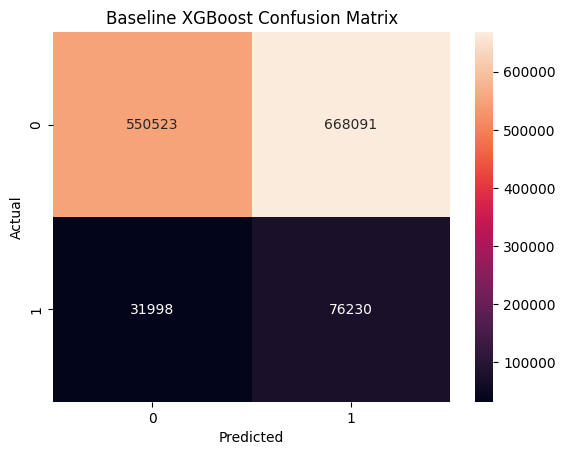

In [26]:
#Confusion Matrix

cm = confusion_matrix(
    y_val,
    y_val_pred
)


sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(
    "Baseline XGBoost Confusion Matrix"
)

plt.show()

STAGE 7 — OPTIMIZATION - Perform hyperparameter tuning

learning_rate
n_estimators
max_depth
subsample

In [27]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay
)
from xgboost import XGBClassifier

In [28]:
# 7.1 Define hyperparameter search space
param_grid = {
    "learning_rate": [0.05, 0.1],
    
    "n_estimators": [200, 300],

    "max_depth": [4, 6],
    
    "subsample": [0.8, 1.0]
}

In [29]:
# 7.2 Create time-aware cross-validation
time_cv = TimeSeriesSplit(n_splits=3)

In [30]:
#Create the XGBoost model
xgb_tuning = XGBClassifier(
    random_state=42,
    eval_metric="logloss",
    scale_pos_weight=scale_weight,
    n_jobs=-1,
    tree_method="hist"
)

In [31]:
# 7.4 Randomized hyperparameter search
random_search = RandomizedSearchCV(
    estimator=xgb_tuning, #uning xgb model
    param_distributions=param_grid,
    n_iter=8,
    scoring="f1",
    cv=time_cv,
    random_state=42,
    verbose=1,
    n_jobs=-1
)

In [33]:
# 7.5 Run hyperparameter tuning
random_search.fit(
    X_train,
    y_train
)

Fitting 3 folds for each of 8 candidates, totalling 24 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'learning_rate': [0.05, 0.1], 'max_depth': [4, 6], 'n_estimators': [200, 300], 'subsample': [0.8, 1.0]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",8
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",TimeSeriesSpl...est_size=None)
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichretur

In [34]:
# 7.6 Display best parameters
print("Best parameters:")
print(random_search.best_params_)

Best parameters:
{'subsample': 1.0, 'n_estimators': 300, 'max_depth': 4, 'learning_rate': 0.1}


In [36]:
#Get the optimized XGBoost model


best_xgb = random_search.best_estimator_

In [37]:
# 7.8 Predict validation data
best_pred = best_xgb.predict(
    X_val
)

best_prob = best_xgb.predict_proba(
    X_val
)[:, 1]

In [38]:
# 7.9 Evaluate optimized XGBoost
optimized_results = evaluate_model(
    y_val,
    best_pred,
    best_prob,
    "Optimized XGBoost"
)

Optimized XGBoost
---------------------
Accuracy: 0.4079
Precision: 0.1005
Recall: 0.7871
F1-score: 0.1782
ROC-AUC: 0.6218


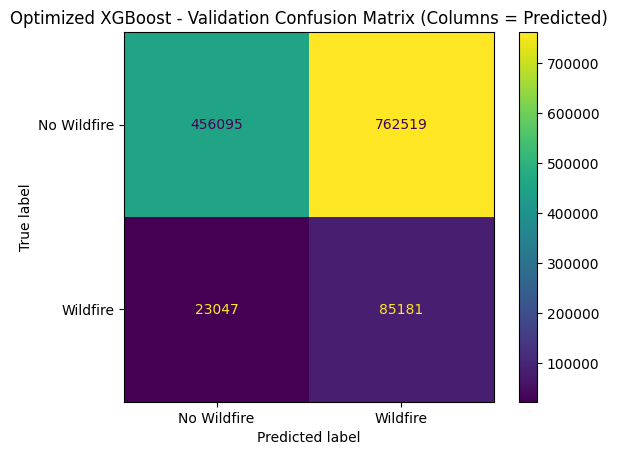

In [62]:
# 7.10 Confusion matrix
cm = confusion_matrix(
    y_val,
    best_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Wildfire", "Wildfire"]
)

disp.plot()

plt.title("Optimized XGBoost - Validation Confusion Matrix (Columns = Predicted)")
plt.show()

Out of all the actual wildfires, how many did our model successfully detect?"

In [40]:
# 7.11 Compare baseline and optimized XGBoost
xgb_comparison = pd.DataFrame([
    baseline_results,
    optimized_results
])

print("Baseline vs Optimized XGBoost")
display(xgb_comparison)

Baseline vs Optimized XGBoost


,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Baseline XGBoost,0.472364,0.102415,0.704346,0.178828,0.619041
1,Optimized XGBoost,0.407943,0.100485,0.787051,0.178216,0.621822


In [41]:
# 7.12 Feature importance
importance = pd.Series(
    best_xgb.feature_importances_,
    index=X_train.columns
)

importance = importance.sort_values(
    ascending=False
)

print(importance)

fuel_moisture_1000hr            0.199652
year                            0.142650
solar_radiation                 0.107867
day_of_year                     0.083133
longitude                       0.071646
latitude                        0.071599
temperature_max                 0.058626
specific_humidity               0.052789
month                           0.048672
precipitation                   0.035403
temperature_min                 0.031938
fuel_moisture_100hr             0.023785
vapor_pressure_deficit          0.014786
potential_evapotranspiration    0.011368
reference_evapotranspiration    0.009632
relative_humidity_max           0.008707
relative_humidity_min           0.008113
energy_release_component        0.007298
burning_index                   0.006420
wind_speed                      0.005915
dtype: float32


In [42]:
# 7.13 Display top 10 features
top_10 = importance.head(10)

print("Top 10 features:")
display(top_10)

Top 10 features:


fuel_moisture_1000hr    0.199652
year                    0.142650
solar_radiation         0.107867
day_of_year             0.083133
longitude               0.071646
latitude                0.071599
temperature_max         0.058626
specific_humidity       0.052789
month                   0.048672
precipitation           0.035403
dtype: float32

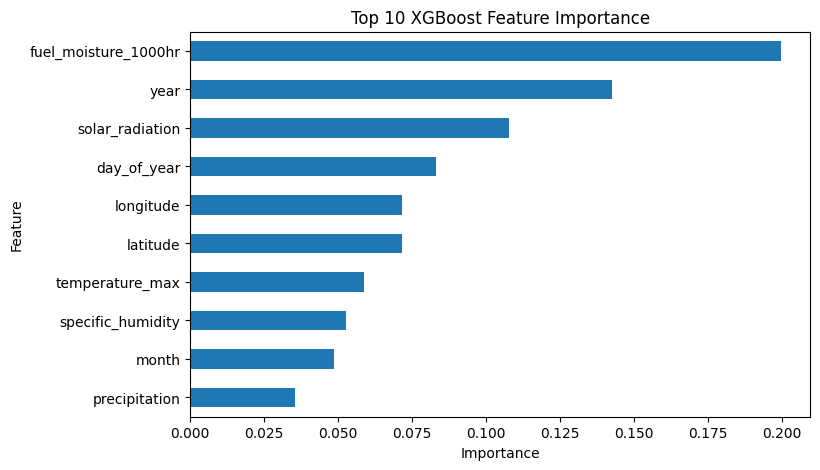

In [43]:
# 7.14 Plot top 10 features
top_10.sort_values().plot(
    kind="barh",
    figsize=(8, 5)
)

plt.title("Top 10 XGBoost Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

In [44]:
# 7.15 Feature selection experiment
selected_features = (
    importance
    .head(10)
    .index
    .tolist()
)

print("Selected features:")
print(selected_features)    

Selected features:
['fuel_moisture_1000hr', 'year', 'solar_radiation', 'day_of_year', 'longitude', 'latitude', 'temperature_max', 'specific_humidity', 'month', 'precipitation']


In [45]:
# 7.16 Create selected-feature datasets
X_train_selected = X_train[
    selected_features
]

X_val_selected = X_val[
    selected_features
]

In [46]:
# 7.17 Train XGBoost using selected features
xgb_selected = XGBClassifier(
    **random_search.best_params_,
    random_state=42,
    eval_metric="logloss",
    scale_pos_weight=scale_weight,
    n_jobs=-1,
    tree_method="hist"
)
xgb_selected.fit(
    X_train_selected,
    y_train
)


,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [47]:
# 7.18 Predict using selected features
selected_pred = xgb_selected.predict(
    X_val_selected
)

selected_prob = xgb_selected.predict_proba(
    X_val_selected
)[:, 1]

In [48]:
# 7.19 Evaluate selected-feature model
selected_results = evaluate_model(
    y_val,
    selected_pred,
    selected_prob,
    "XGBoost - Selected Features"
)

XGBoost - Selected Features
---------------------
Accuracy: 0.4141
Precision: 0.1000
Recall: 0.7724
F1-score: 0.1770
ROC-AUC: 0.6201


In [49]:
# 7.20 Compare all XGBoost experiments
xgb_final_comparison = pd.DataFrame([
    baseline_results,
    optimized_results,
    selected_results
])

print("XGBoost Experiment Comparison")
display(xgb_final_comparison)

XGBoost Experiment Comparison


,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Baseline XGBoost,0.472364,0.102415,0.704346,0.178828,0.619041
1,Optimized XGBoost,0.407943,0.100485,0.787051,0.178216,0.621822
2,XGBoost - Selected Features,0.414119,0.099954,0.772397,0.177003,0.620076


In [51]:
# 7.21 Experiment documentation


experiment_log = pd.DataFrame([
    {
        "Experiment": "EXP-01",
        "Model": "XGBoost",
        "Change": "Baseline parameters",
        "Purpose": "Establish baseline performance"
    },
    {
        "Experiment": "EXP-02",
        "Model": "XGBoost",
        "Change": "Hyperparameter tuning",
        "Purpose": "Investigate parameter optimization"
    },
    {
        "Experiment": "EXP-03",
        "Model": "XGBoost",
        "Change": "Feature selection",
        "Purpose": "Investigate whether fewer features improve performance"
    }
])

display(experiment_log)

,Experiment,Model,Change,Purpose
0,EXP-01,XGBoost,Baseline parameters,Establish baseline performance
1,EXP-02,XGBoost,Hyperparameter tuning,Investigate parameter optimization
2,EXP-03,XGBoost,Feature selection,Investigate whether fewer features improve per...


| Model |                      Accuracy | Precision | Recall | F1 | ROC-AUC |
|---|---:|---:|---:|---:|---:|
| Logistic Regression |          0.5817 | 0.1066 | 0.5590 | 0.1790 | 0.6037 |
| Random Forest |                0.5433 | 0.1076 | 0.6303 |*0.1838* *0.6222** |
| Decision Tree |                0.4243 | 0.1006 | 0.7626 | 0.1777 | 0.6037 |
| **XGBoost** |                  *0.4079* 0.1005 | *0.7871* 0.1782 | 0.6218 |

In [52]:
# Validation results of all four models

model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        0.581698,
        0.4243,
        0.543298,
        0.407943   


    ],
    "Precision": [
        0.1066,
        0.1006,
        0.107568,
        0.100485
    ],
    
    "Recall": [
        0.5590,
        0.7626,
        0.630308,
        0.787051
    ],
    
    "F1-score": [
        0.1790,
        0.1777,
        0.183773,
        0.178216
    ],
    
    "ROC-AUC": [
        0.6037,
        0.6037,
        0.622228,
        0.621822
    ],

})

model_comparison


,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression,0.581698,0.106600,0.559000,0.179000,0.603700
1,Decision Tree,0.424300,0.100600,0.762600,0.177700,0.603700
2,Random Forest,0.543298,0.107568,0.630308,0.183773,0.622228
3,XGBoost,0.407943,0.100485,0.787051,0.178216,0.621822


# Stage 7 — Final Model Comparison and Selection

This notebook compares the four machine learning models developed for wildfire prediction using the validation set.

Models:
- Logistic Regression
- Decision Tree
- Random Forest
- XGBoost

The best-performing model will be selected based on the validation results. The selected model will then be evaluated on the completely unseen test set.


In [53]:
# ============================================
# FINAL MODEL EVALUATION
# ============================================

# Predict on the untouched test set
final_test_pred = best_xgb.predict(X_test)

final_test_prob = best_xgb.predict_proba(X_test)[:, 1]


# Evaluate final model
final_test_results = evaluate_model(
    y_test,
    final_test_pred,
    final_test_prob,
    "Final XGBoost - Test"
)

print("\nFinal Test Results:")
display(
    pd.DataFrame([final_test_results])
)

Final XGBoost - Test
---------------------
Accuracy: 0.4815
Precision: 0.1692
Recall: 0.6673
F1-score: 0.2700
ROC-AUC: 0.5858

Final Test Results:


,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Final XGBoost - Test,0.481502,0.169237,0.667345,0.270002,0.585835


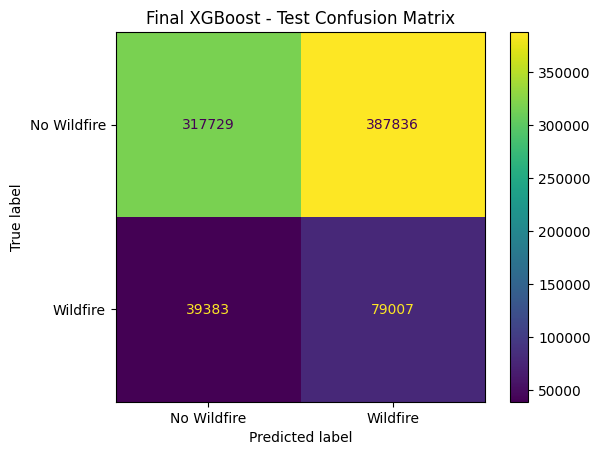

In [54]:
# ============================================
# FINAL CONFUSION MATRIX
# ============================================

cm = confusion_matrix(
    y_test,
    final_test_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Wildfire", "Wildfire"]
)

disp.plot()

plt.title(
    "Final XGBoost - Test Confusion Matrix"
)

plt.show()

In [58]:
# ============================================
# SAVE FINAL MODEL
# ============================================

import joblib
import os

# Notebook is in ml/notebooks/
# Models folder is in ml/models/
model_path = "../models/xgboost_final.joblib"

joblib.dump(
    best_xgb,
    model_path
)

print(
    "Model saved:",
    os.path.exists(model_path)
)

print(
    "Model path:",
    os.path.abspath(model_path)
)

Model saved: True
Model path: c:\Users\UMAR\Documents\GitHub\fdm-mini-project\ml\models\xgboost_final.joblib


In [59]:
# ============================================
# SAVE FEATURE NAMES
# ============================================

feature_names = X_train.columns.tolist()

feature_path = "../models/xgboost_feature_names.joblib"

joblib.dump(
    feature_names,
    feature_path
)

print(
    "Feature list saved:",
    os.path.exists(feature_path)
)

print(
    "Number of features:",
    len(feature_names)
)

print(
    "Features:",
    feature_names
)

Feature list saved: True
Number of features: 20
Features: ['latitude', 'longitude', 'precipitation', 'relative_humidity_max', 'relative_humidity_min', 'specific_humidity', 'solar_radiation', 'temperature_min', 'temperature_max', 'wind_speed', 'burning_index', 'fuel_moisture_100hr', 'fuel_moisture_1000hr', 'energy_release_component', 'reference_evapotranspiration', 'potential_evapotranspiration', 'vapor_pressure_deficit', 'year', 'month', 'day_of_year']


In [60]:
# ============================================
# VERIFY SAVED MODEL
# ============================================

loaded_model = joblib.load(
    model_path
)

loaded_pred = loaded_model.predict(
    X_test
)

print(
    "Saved model predictions match:",
    (loaded_pred == final_test_pred).all()
)

Saved model predictions match: True
